# Neural Posterior Estimation for LISA
## Part 2 — the background is binaries: inference under a galactic population

**Tutorial by Max Dax, building on Stephen Green's
[LISAAI-Hackathon-ESTEC](https://github.com/stephengreen/LISAAI-Hackathon-ESTEC) tutorial**

Part 1 built a catalog pipeline from a frozen single-source network, and ended on two
warnings: the white-noise floor was a simplification, and the single-source model broke,
detectably but unfixably, when two binaries shared a tile. This notebook repairs both, and
the repair happens in one place: the training distribution.

Everything here is generated by a single **population prior**: a Poisson process in
frequency with a power-law amplitude distribution. Its loud tail is the catalog, its faint
bulk is the confusion background, and the boundary between them is a property of the
analysis, not of the simulation. The network is retrained (once) to answer the question this
data actually poses per tile: *what is the loudest source in this tile, whatever else is in
the band?* Same scan as Part 1, same input format, a new assumed world.

<!-- ---

### Roadmap (about 40 minutes)

| | | |
|---|---|---|
| 1 | The data: a population, not an injection list | ~5 min |
| 2 | A record from the population | ~3 min |
| 3 | Part 1's pipeline breaks here | ~3 min |
| 4 | The repair: loudest-in-tile NPE | ~5 min |
| 5 | Calibration: P-P over the population | ~4 min |
| 6 | The catalog, without importance sampling | ~6 min |
| 7 | What the two networks think the data contains | ~4 min |
| 8 | Two sources in one tile | ~6 min |
| 9 | Iterative subtraction | ~4 min |
| 10 | Exercises and outlook | remainder |

-->

New machinery lives in `gb_population.py`; the network was trained by
`train_confusion_flow.py` (a script, since the notebook never trains live: the checkpoint in
`checkpoints/` was produced by exactly that script and stores the population it was trained
for).

In [1]:
# Guarded so that this is a no-op where the packages already exist (e.g. a uv-managed venv);
# on a bare Colab runtime it installs.
import importlib.util
import sys

if any(importlib.util.find_spec(pkg) is None for pkg in ("glasflow", "corner")):
    !{sys.executable} -m pip install -q glasflow corner

In [2]:
# On Colab, fetch the tutorial modules and the trained networks. No-op from a repo clone.
import os
import urllib.request

MODEL = "s"      # Part 2 network size: "s" or "m" (in the repo), "l" (release asset)
P2_CKPT = f"checkpoints/part2_population_flow_{MODEL}.pt"
REPO_RAW = "https://github.com/max-dax/LISAI-2026-GB-tutorial/raw/main"
RELEASE = "https://github.com/max-dax/LISAI-2026-GB-tutorial/releases/download/models-v1"
for f in ["gb_simulator.py", "gb_wide.py", "gb_catalog.py", "gb_population.py",
          "checkpoints/part1_flow_v2.pt", P2_CKPT]:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
        if f == P2_CKPT and MODEL == "l":
            urllib.request.urlretrieve(f"{RELEASE}/{os.path.basename(f)}", f)
        else:
            urllib.request.urlretrieve(f"{REPO_RAW}/{f}", f)

In [3]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats as sps

import gb_simulator as gb
import gb_wide as gbw
import gb_catalog as gbc
import gb_population as gbp
from gb_simulator import N, device
from gb_wide import DF_P1, TILE_HALF

print(f"device: {device}")

device: cpu


---
# 1. The data: a population, not an injection list

<!-- *(~5 min)* -->

The data format is Part 1's (see its section 0 for the full story): the record is the
**complex envelope** of the strain after heterodyning by $F_{\rm ref} = 3$ mHz, a time
series of 51,200 complex samples covering four years, with frequencies quoted as offsets
$\delta f \in \pm 100\,\mu$Hz from the carrier. The scan also works as before: demodulate by
each tile's proxy, keep the central 256 frequency bins, and hand the result to a network.

What changes is where the record comes from. Part 1 placed 40 hand-picked sources into white
noise. Here a single **population prior** generates every source in the band:

- **frequencies**: a Poisson process with density $\rho = 150$ sources per $\mu$Hz, about
  30,000 binaries in the record. That is the right order of magnitude for the real Galaxy,
  which holds $\sim 10^7$ double white dwarfs in the LISA band.
- **amplitudes**: a power law $dN/dA \propto A^{-3.3}$ on $A \in [0.1, 7]$. The rare loud
  tail (about 150 sources above SNR 8) is what a catalog can claim; the faint bulk adds up
  to a confusion floor whose in-band power is about twice the instrument noise.
- the other parameters ($\dot f$, $\phi_0$, $\cos\iota$) follow Part 1's priors.

Three nested windows organize everything (source counts for $\rho = 150/\mu$Hz):

| window | width | role | sources |
|---|---|---|---|
| tile | $0.1\,\mu$Hz | what a network is *responsible* for | ~15 |
| retained band | $\pm 1.01\,\mu$Hz | what a network *sees* | ~300 |
| record | $\pm 100\,\mu$Hz | what the scan covers | ~30,000 |

Tiles partition the axis, so every source is the responsibility of exactly one tile; bands
overlap almost completely between neighboring tiles, so the same source is *visible* to
about twenty. And because the instrument-noise level is just a setting, we can turn it off
entirely: what is left is not silence but the Galaxy itself, which is the point of this
notebook's title.

One convention deserves care before any code, because anyone from the LVK world will ask.
The inference target per tile is "the loudest in-tile source", and **loudness is defined
from the injection parameters** — the noise-free SNR $\lVert s(\theta) \rVert$ — not from
any data-dependent matched-filter statistic. In simulation-based training we have the
latent parameters, so the label is a deterministic function of them, and training on
(label, data) pairs yields the correct posterior for that well-defined quantity. A
data-dependent definition would make the target a property of the noise realization, and
the same physical source would switch identity between realizations.

The ambiguity that motivates data-dependent definitions does not disappear; it moves to
where it belongs. When two in-tile sources have nearly equal true SNR, the data cannot
determine which is the louder, and the correct posterior over the label is **bimodal**,
with mass on each source in proportion to the probability that it is the true winner.
Section 8 tests exactly this.

---
# 2. A record from the population

<!-- *(~3 min)* -->

Draw the population, sum it onto the wide grid twice, once with instrument noise and once
without, and look at the spectra. The pipeline settings are Part 1's ($W = 1000$, 2000
tiles).

In [4]:
pop = gbp.PopulationSettings()          # rho=150/uHz, alpha=3.3, A in [0.1, 7], noise 1.0
quiet = gbp.PopulationSettings(noise_std=0.0)
W = 1000
K = gbc.configure(gbc.CatalogSettings(w=W))

theta_pop = gbp.sample_population(pop, w=W, seed=2026)
snr_pop = torch.cat([gbw.signal_wide(theta_pop[i:i + 2000]).pow(2).sum(-1).sqrt()
                     for i in range(0, len(theta_pop), 2000)])
t0 = time.time()
d = gbp.make_record(theta_pop, pop, seed=1)
d_quiet = gbp.make_record(theta_pop, quiet, seed=1)
print(f"{len(theta_pop):,} sources in {time.time() - t0:.0f} s; "
      f"SNR > 8: {int((snr_pop > 8).sum())}, SNR > 20: {int((snr_pop > 20).sum())}, "
      f"loudest {snr_pop.max():.0f}")
print(f"confusion power per wide sample: {d_quiet.var():.2f} of {gb.NOISE_STD**2:.2f} "
      "instrument; the sources occupy half the wide bandwidth, so in-band the "
      "confusion carries about twice the instrument power")

29,849 sources in 16 s; SNR > 8: 148, SNR > 20: 24, loudest 50
confusion power per wide sample: 1.01 of 1.00 instrument; the sources occupy half the wide bandwidth, so in-band the confusion carries about twice the instrument power


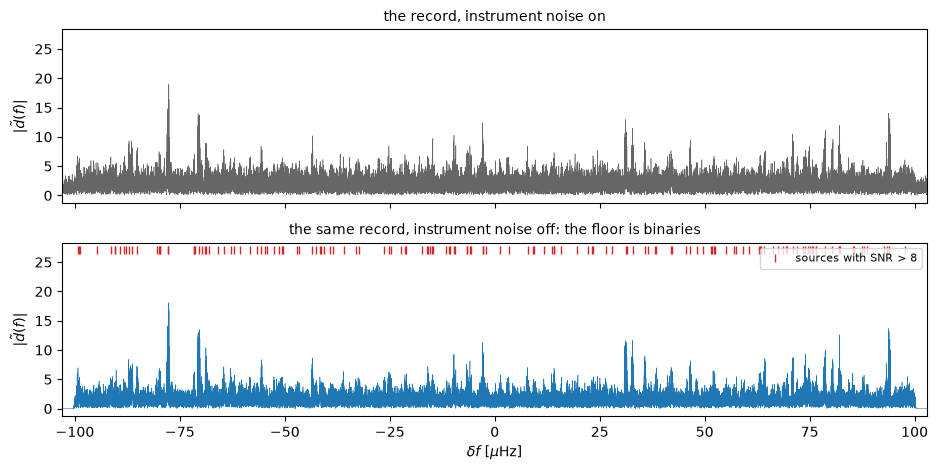

In [5]:
DT_WIDE = (gbw.t_wide[1] - gbw.t_wide[0]).item()
f_axis = np.fft.fftshift(np.fft.fftfreq(gbw.N_WIDE, d=DT_WIDE)) * 1e6


def spectrum(x):
    z = torch.complex(x[:gbw.N_WIDE], x[gbw.N_WIDE:]).cpu().numpy()
    return np.abs(np.fft.fftshift(np.fft.fft(z))) / np.sqrt(gbw.N_WIDE)


fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.8), sharex=True, sharey=True)
axes[0].plot(f_axis, spectrum(d), lw=0.4, color="0.4")
axes[0].set_title("the record, instrument noise on", fontsize=10)
axes[1].plot(f_axis, spectrum(d_quiet), lw=0.4, color="C0")
loud = (snr_pop > 8).cpu()
axes[1].plot(theta_pop[loud, 1].cpu() * 1e6, np.full(int(loud.sum()), 27.0), "|",
             color="C3", ms=6, label="sources with SNR > 8")
axes[1].set_title("the same record, instrument noise off: the floor is binaries",
                  fontsize=10)
axes[1].set_xlim(-103, 103)
axes[1].set_xlabel(r"$\delta f\ [\mu{\rm Hz}]$")
axes[1].legend(fontsize=8, loc="upper right")
for ax in axes:
    ax.set_ylabel(r"$|\tilde d(f)|$")
plt.tight_layout()

The lower panel is the notebook's thesis in one picture. With the instrument switched off
the floor does not vanish: tens of thousands of individually invisible binaries add up to a
dense, fluctuating background, and the loud sources stand on top of it. "Noise", for the
loud tail of the population, is mostly the faint end of the same population.

---
# 3. Part 1's pipeline breaks here

<!-- *(~3 min)* -->

Part 1's scan is not wrong on its own terms; its terms assumed white unit noise. Run the
frozen Part 1 network and its evidence scan on this record, with the same noise-only
threshold calibration as in Part 1, and count what it claims.

In [6]:
flow_p1 = gbc.load_part1_flow("checkpoints/part1_flow_v2.pt")
d_cond = gbc.condition_all(d)

t0 = time.time()
res_p1 = gbc.scan(flow_p1, d_cond, n_draws=512)
torch.manual_seed(2)
white = torch.randn(2 * gbw.N_WIDE, device=device)
thr_p1 = gbc.scan(flow_p1, gbc.condition_all(white), n_draws=512)["log_B"].max().item() + 2.0

truth_tile, truth_snr = gbp.loudest_per_tile(theta_pop, w=W)
claimed = res_p1["log_B"] > thr_p1
print(f"scan in {time.time() - t0:.0f} s; Part 1 threshold {thr_p1:.1f}")
print(f"{int(claimed.sum())} of {K} tiles claimed as detections; "
      f"only {int((truth_snr > 8).sum())} tiles actually hold a source above SNR 8")

scan in 81 s; Part 1 threshold 1.7
304 of 2000 tiles claimed as detections; only 145 tiles actually hold a source above SNR 8


The white-noise calibration priced false alarms for a floor that no longer exists: the
confusion background lifts the evidence everywhere, and the scan claims about twice as many
tiles as truly hold a catalog source. Recalibrating the threshold on a confusion
realization would fix the count but not the deeper problem: the network's posteriors assume
a single source in white noise, so their widths cannot account for the elevated floor or
for the neighbors in the band. Sections 5 and 7 show that failure quantitatively and
visually; first, the repair.

---
# 4. The repair: loudest-in-tile NPE

<!-- *(~5 min)* -->

Retraining needs pairs (label, data) drawn from the population. The data half sounds
expensive, a 30,000-source record per example, but a Poisson population has the property
that its restriction to a band is again a Poisson population. So training examples are
generated **band-locally**: draw the ~375 sources within $\pm 1.25\,\mu$Hz of a tile
center, sum their conditioned waveforms (via a precomputed bank, since amplitude and phase
act on a stored waveform exactly), add instrument noise. The label is the loudest in-tile
source. No record is ever built.

The claim that the band generator equals the record restriction is checkable, so check it:
generate both, compare the confusion variance per feature. (Agreement is up to the
realization scatter of one record's loud tail, a few per cent.)

In [7]:
bank = gbp.build_bank(pop, n_bank=16384)     # a small demo bank; training used 4M entries
d_ex, th_ex, snr_ex = gbp.sample_tiles(bank, 4096, pop, seed=5)

d_cond_quiet = gbc.condition_all(d_quiet)
d_band_quiet, _, _ = gbp.sample_tiles(bank, 2048, quiet, seed=6)
print(f"clean confusion variance per feature: record tiles {d_cond_quiet.var():.3f}, "
      f"band generator {d_band_quiet.var():.3f}")
print(f"label SNR across training examples: median {snr_ex.median():.1f}, "
      f"90% quantile {snr_ex.quantile(0.9):.1f}, max {snr_ex.max():.0f}")

clean confusion variance per feature: record tiles 2.034, band generator 1.926
label SNR across training examples: median 2.9, 90% quantile 6.6, max 73


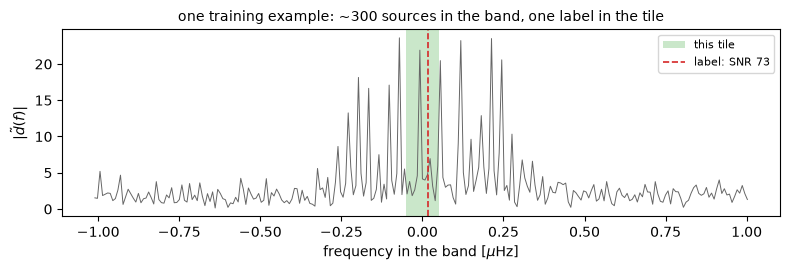

In [8]:
i_show = int(snr_ex.argmax())                # the loudest labelled example of the batch
f_band = np.fft.fftshift(np.fft.fftfreq(N, d=gbw.DT)) * 1e6
z_show = torch.complex(d_ex[i_show, :N], d_ex[i_show, N:]).cpu().numpy()

plt.figure(figsize=(8, 2.8))
plt.plot(f_band, np.abs(np.fft.fftshift(np.fft.fft(z_show))) / np.sqrt(N), lw=0.7,
         color="0.4")
plt.axvspan(-TILE_HALF * 1e6, TILE_HALF * 1e6, color="C2", alpha=0.25, lw=0,
            label="this tile")
plt.axvline(float(th_ex[i_show, 1]) * 1e6, color="C3", lw=1.2, ls="--",
            label=f"label: SNR {snr_ex[i_show]:.0f}")
plt.xlabel(r"frequency in the band $[\mu{\rm Hz}]$"); plt.ylabel(r"$|\tilde d(f)|$")
plt.title("one training example: ~300 sources in the band, one label in the tile",
          fontsize=10)
plt.legend(fontsize=8); plt.tight_layout()

The network itself is Part 1's construction with the affine autoregressive step replaced
by a rational-quadratic **spline** step: per-tile posteriors here are routinely
non-Gaussian (railed amplitudes for the faint majority, and the bimodal near-ties of
section 8), and training on fresh simulations every batch removes the overfitting risk
that capacity otherwise carries. Training happened in `train_confusion_flow.py`, not here;
the checkpoint records the population it was trained for, which must be the one this
notebook analyzes.

arch {'arch': 'nsf', 'num_flow_steps': 6, 'hidden_dim': 128, 'num_bins': 8}; 30,000 steps x batch 2048 = 61M fresh examples, 15 min on cuda


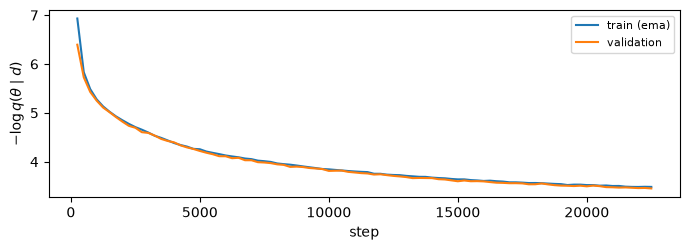

In [9]:
flow2, stats, pop_trained = gbp.load_population_flow(P2_CKPT)
assert pop_trained == pop, "checkpoint was trained for a different population"
ckpt = torch.load(P2_CKPT, map_location="cpu",
                  weights_only=False)
h = ckpt["history"]
print(f"arch {ckpt['arch']}; {ckpt['meta']['steps']:,} steps x batch "
      f"{ckpt['meta']['batch']} = {ckpt['meta']['steps'] * ckpt['meta']['batch'] / 1e6:.0f}M "
      f"fresh examples, {ckpt['meta']['seconds'] / 60:.0f} min on {ckpt['meta']['device']}")

plt.figure(figsize=(7, 2.6))
plt.plot(h["step"], h["train"], label="train (ema)")
plt.plot(h["step"], h["val"], label="validation")
plt.xlabel("step"); plt.ylabel(r"$-\log q(\theta \mid d)$")
plt.legend(fontsize=8); plt.tight_layout()

---
# 5. Calibration: P-P over the population

<!-- *(~4 min)* -->

The importance-sampling certificate of Parts 1 and 2a is gone: the trained posterior
marginalizes over every unlabelled source in the band, so there is no per-event likelihood
to reweight against. What remains is the population-level test, and under the
population-matched training convention it is exact: draw fresh records, read off the true
loudest-in-tile source, and check that its quantiles under the network's posteriors are
uniform. This is run on full records, generated independently of the training bank, so it
also tests the band-local shortcut end to end.

Both networks take the identical test on the identical 400 tiles, so the two panels are
directly comparable. The Part 1 network cannot even represent much of the truth (labels
below its amplitude floor of 1.4, residual frequencies at the tile scale), and the P-P
curves display that honestly: quantiles pile at 0 or 1 whenever the truth lies outside the
support of its posterior.

In [10]:
theta_val = gbp.sample_population(pop, w=W, seed=777)
d_val = gbp.make_record(theta_val, pop, seed=778)
truth_val, snr_val = gbp.loudest_per_tile(theta_val, w=W)
d_cond_val = gbc.condition_all(d_val)

torch.manual_seed(3)
pick = torch.randperm(K)[:400]
truth_res = truth_val[pick].clone()
truth_res[:, 1] = truth_res[:, 1] - gbw.DF_HAT[pick]         # residual delta f

t0 = time.time()
draws_val, _ = gbp.tile_posterior_draws(flow2, stats, d_cond_val[pick], n_draws=1000)
q2 = (draws_val < truth_res[:, None, :]).float().mean(1).cpu().numpy()

with torch.no_grad():
    zp, _ = flow_p1.sample_and_log_prob(1000, d_cond_val[pick])
draws_p1 = zp * gbc.P1_STD + gbc.P1_MEAN
q1 = (draws_p1 < truth_res[:, None, :]).float().mean(1).cpu().numpy()
print(f"{len(pick)} injection tiles, both networks, in {time.time() - t0:.0f} s")

400 injection tiles, both networks, in 31 s


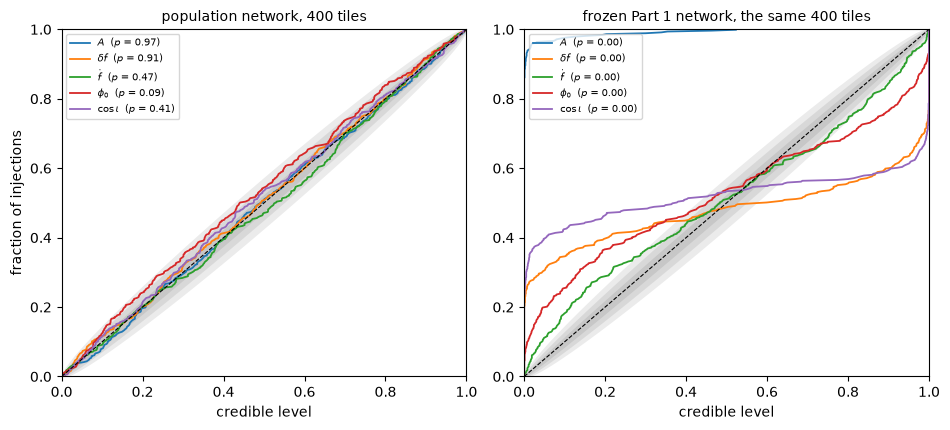

In [11]:
LABELS = [r"$A$", r"$\delta f$", r"$\dot f$", r"$\phi_0$", r"$\cos\iota$"]


def pp_panel(ax, q, title):
    n, dim = q.shape
    k = np.arange(1, n + 1)
    y = (k - 0.5) / n
    for c in (0.68, 0.95, 0.997):
        ax.fill_betweenx(y, sps.beta.ppf((1 - c) / 2, k, n + 1 - k),
                         sps.beta.ppf((1 + c) / 2, k, n + 1 - k), color="k", alpha=0.08,
                         lw=0)
    for j in range(dim):
        p = sps.kstest(q[:, j], "uniform").pvalue
        ax.plot(np.sort(q[:, j]), y, lw=1.3, label=f"{LABELS[j]}  ($p$ = {p:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("credible level")
    ax.legend(fontsize=7, loc="upper left")


fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4))
pp_panel(axes[0], q2, f"population network, {len(pick)} tiles")
pp_panel(axes[1], q1, f"frozen Part 1 network, the same {len(pick)} tiles")
axes[0].set_ylabel("fraction of injections")
plt.tight_layout()

The population network is calibrated across the board, faint labels included. The Part 1
network is not calibrated in any parameter, and the amplitude curve shows why most
directly: the majority of true labels lie below its prior floor, where its posterior
carries no mass at all. This is not a fixable per-event error; the assumed data-generating
process has to match the data.

---
# 6. The catalog, without importance sampling

<!-- *(~6 min)* -->

Detection becomes a posterior statement. The network can express "the loudest source in
this tile is negligible", because faint labels dominated its training diet; so the scan
asks each tile for its posterior on the label's SNR, and the catalog keeps tiles where the
median posterior SNR exceeds the catalog floor of 8. No evidence integral, no importance
weights, one forward pass per tile.

One catalog-level detail needs handling before scoring. A loud source that sits within a
few nanohertz of a tile boundary is legitimately claimed by *both* neighboring tiles: each
tile's posterior correctly says "the loudest source in my tile is either that monster, if
it falls on my side of the line, or something faint". Per tile that is calibrated
(section 5 just certified it); as catalog rows it is one source counted twice. So adjacent
detections whose frequency estimates agree to within a few nanohertz are merged, keeping
the tile with the tighter frequency posterior. Scoring then matches by frequency rather
than by tile, an entry being correct when a true source above the floor lies within the
entry's own 3-sigma frequency uncertainty: which tile files the claim is bookkeeping.

In [12]:
t0 = time.time()
draws_all, snr_draws = gbp.tile_posterior_draws(flow2, stats, d_cond, n_draws=256)
stat = snr_draws.median(-1).values
print(f"full scan: {K} tiles in {time.time() - t0:.0f} s")

SNR_CAT = 8.0


def dedup(det_tiles, draws, stat_val, merge_nhz=3.0):
    # merge adjacent detected tiles claiming the same frequency -> kept, dropped
    f_med = torch.tensor([float(gbw.DF_HAT[k] + draws[k, :, 1].median()) for k in det_tiles])
    sig_f = torch.tensor([float(draws[k, :, 1].std()) for k in det_tiles])
    keep = []
    dropped = []
    for i, k in enumerate(det_tiles):
        dup = [j for j, k2 in enumerate(det_tiles)
               if abs(k2 - k) == 1 and abs(f_med[j] - f_med[i]) < merge_nhz * 1e-9]
        if any(sig_f[j] < sig_f[i] for j in dup):
            dropped.append(int(k))
        else:
            keep.append(int(k))
    return keep, dropped


det_tiles = torch.nonzero(stat > SNR_CAT).flatten().tolist()
cat_tiles, dup_tiles = dedup(det_tiles, draws_all, stat)

# Score by frequency, not by tile: which tile claims a boundary source is bookkeeping.
# An entry is correct if its claimed frequency lands within 5 nHz of a true source above
# the floor; a true source is found if any entry lands on it.
f_claim = torch.tensor([float(gbw.DF_HAT[k] + draws_all[k, :, 1].median())
                        for k in cat_tiles])
r_claim = torch.tensor([float(draws_all[k, :, 1].std()) for k in cat_tiles])     .mul(3).clamp(min=5e-9)                    # per-entry 3 sigma, floored at 5 nHz
f_true = theta_pop[snr_pop > SNR_CAT, 1].cpu()
dmat = (f_claim[:, None] - f_true[None, :]).abs()
entry_ok = (dmat < r_claim[:, None]).any(1)
src_found = (dmat < r_claim[:, None]).any(0)
print(f"{len(det_tiles)} tiles above the cut, {len(dup_tiles)} boundary duplicates merged "
      f"-> {len(cat_tiles)} catalog entries")
print(f"true sources above SNR 8: {len(f_true)}; "
      f"completeness {src_found.float().mean():.2f}, "
      f"purity {entry_ok.float().mean():.2f}")

full scan: 2000 tiles in 32 s
118 tiles above the cut, 2 boundary duplicates merged -> 116 catalog entries
true sources above SNR 8: 148; completeness 0.74, purity 0.94


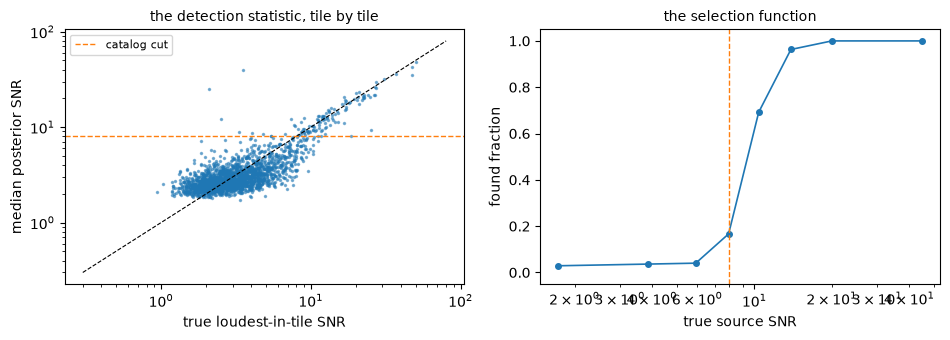

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.5))

ok = truth_snr > 0
axes[0].plot(truth_snr[ok].cpu(), stat[ok].cpu(), ".", ms=3, color="C0", alpha=0.5)
axes[0].plot([0.3, 80], [0.3, 80], "k--", lw=0.8)
axes[0].axhline(SNR_CAT, color="C1", ls="--", lw=1.0, label="catalog cut")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("true loudest-in-tile SNR"); axes[0].set_ylabel("median posterior SNR")
axes[0].set_title("the detection statistic, tile by tile", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")

edges = np.array([1, 3, 5, 7, 9, 12, 16, 25, 80])
mids = np.sqrt(edges[:-1] * edges[1:])
sel = snr_pop > 1
s_np = snr_pop[sel].cpu().numpy()
d_src = ((f_claim[:, None] - theta_pop[sel, 1][None, :].cpu()).abs()
         < r_claim[:, None]).any(0)
det_np = d_src.numpy()
frac = [det_np[(s_np >= a) & (s_np < b)].mean() if ((s_np >= a) & (s_np < b)).any()
        else np.nan for a, b in zip(edges[:-1], edges[1:])]
axes[1].semilogx(mids, frac, "o-", color="C0", lw=1.2, ms=4)
axes[1].axvline(SNR_CAT, color="C1", ls="--", lw=1.0)
axes[1].set_xlabel("true source SNR"); axes[1].set_ylabel("found fraction")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("the selection function", fontsize=10)
plt.tight_layout()

Now the catalog itself, as posteriors rather than numbers: the twelve loudest entries, one
per row, with the marginal posteriors of frequency, amplitude, and SNR against the true
loudest-in-tile source of that tile. Frequency is shown relative to the posterior median,
so the axis is nanohertz regardless of where in the band the source sits. Setting
`OVERLAY_P1` overlays the frozen Part 1 network's posteriors for the same tiles as thin
steps; the y-scale follows the population network, so where Part 1 is overconfident its
spike simply leaves the frame.

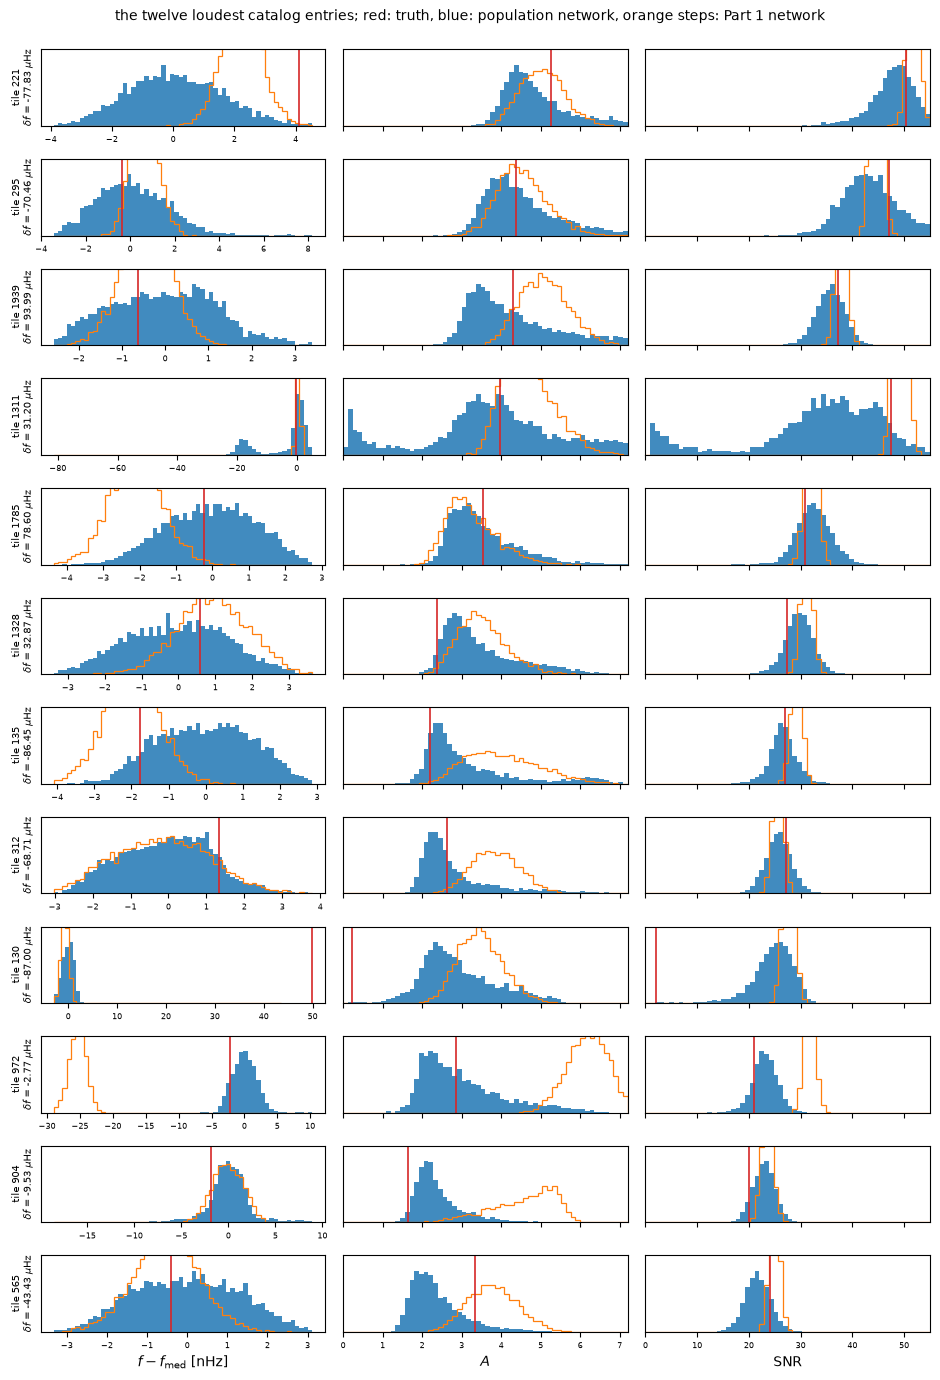

In [14]:
top = sorted(cat_tiles, key=lambda k: -float(stat[k]))[:12]
draws_top, snr_top = gbp.tile_posterior_draws(flow2, stats, d_cond[top], n_draws=4000)

OVERLAY_P1 = True          # overlay the frozen Part 1 network's posteriors as thin steps
if OVERLAY_P1:
    with torch.no_grad():
        zz, _ = flow_p1.sample_and_log_prob(4000, d_cond[top])
    p1_top = zz * gbc.P1_STD + gbc.P1_MEAN
    p1_snr = gb.signal(p1_top.reshape(-1, 5)).pow(2).sum(-1).sqrt() \
        .reshape(p1_top.shape[:2])

fig, axes = plt.subplots(len(top), 3, figsize=(9.5, 1.15 * len(top)))
for r, k in enumerate(top):
    th_k, snr_k = draws_top[r], snr_top[r]
    f0 = float(th_k[:, 1].median())
    truth_f = float(truth_tile[k, 1] - gbw.DF_HAT[k])
    p1_f = (p1_top[r][:, 1] - f0).cpu().numpy() * 1e9 if OVERLAY_P1 else None
    for c, (x, x1, tr, lab) in enumerate([
            ((th_k[:, 1] - f0).cpu().numpy() * 1e9, p1_f, (truth_f - f0) * 1e9,
             r"$f - f_{\rm med}$ [nHz]"),
            (th_k[:, 0].cpu().numpy(),
             p1_top[r][:, 0].cpu().numpy() if OVERLAY_P1 else None,
             float(truth_tile[k, 0]), r"$A$"),
            (snr_k.cpu().numpy(), p1_snr[r].cpu().numpy() if OVERLAY_P1 else None,
             float(truth_snr[k]), "SNR")]):
        ax = axes[r, c]
        if c == 0:
            both = np.concatenate([x, x1]) if OVERLAY_P1 else x
            rng = tuple(np.percentile(both, [0.2, 99.8]))
        else:
            rng = (0, 7.2) if c == 1 else (0, 55)
        n2, bins2, _ = ax.hist(x, bins=60, range=rng, density=True, color="C0",
                               alpha=0.85)
        if OVERLAY_P1:
            ax.hist(x1, bins=bins2, density=True, histtype="step", color="C1", lw=0.9)
            ax.set_ylim(0, n2.max() * 1.25)
        ax.axvline(tr, color="C3", lw=1.2)
        ax.set_yticks([])
        if c > 0:
            ax.set_xlim(rng)
        ax.tick_params(axis="x", labelsize=6)
        if c > 0 and r < len(top) - 1:
            ax.set_xticklabels([])
        if r == len(top) - 1:
            ax.set_xlabel(lab)
    axes[r, 0].set_ylabel(f"tile {k}\n" rf"$\delta f$ = {(gbw.DF_HAT[k] + f0) * 1e6:.2f} "
                          r"$\mu$Hz", fontsize=7)
fig.suptitle("the twelve loudest catalog entries; red: truth, blue: population network"
             + (", orange steps: Part 1 network" if OVERLAY_P1 else ""),
             fontsize=10, y=0.997)
plt.tight_layout()

Compare the error bars with Part 1's catalog: frequencies are still measured to nanohertz,
but the uncertainties are wider than they were under white noise, and correctly so, since
the P-P test certified them. The confusion background is not an obstacle the pipeline
fights; it is part of the noise model the posterior now honestly reports.

---
# 7. What the two networks think the data contains

<!-- *(~4 min)* -->

Numbers certify; pictures explain. For three tiles, a loud one, a marginal one, and a
crowded one, draw from each network's posterior, push the draws through the waveform model,
and compare the **posterior predictive** signal spectrum with the data and with the true
noise-free signal content of the band. Each network reconstructs only what it models: its
labelled source, not the whole band.

tiles: loud 221 (true SNR 50), marginal 1222 (true SNR 9), crowded 1758 (5 loud sources in band)


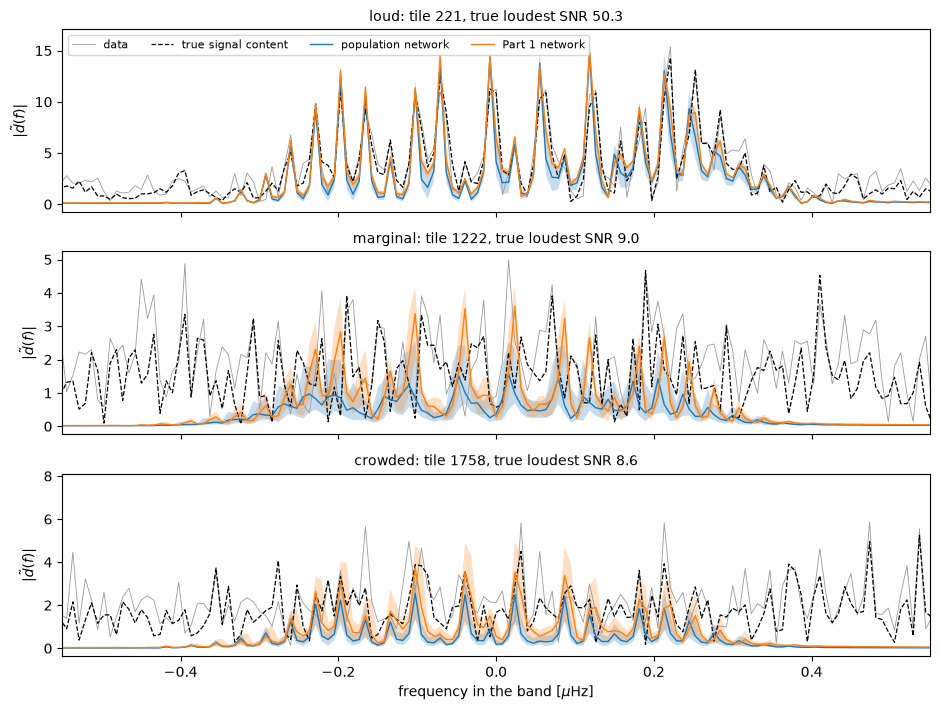

In [15]:
def predictive_band(theta_draws):
    # per-frequency-bin quantiles of |s(f)| over posterior draws
    s = gb.signal(theta_draws)
    z = torch.complex(s[:, :N], s[:, N:])
    F = torch.fft.fftshift(torch.fft.fft(z), dim=-1).abs() / np.sqrt(N)
    q = torch.quantile(F, torch.tensor([0.16, 0.5, 0.84], device=device), dim=0)
    return q.cpu().numpy()


crowd = torch.tensor([int(((theta_pop[:, 1] - gbw.DF_HAT[k]).abs() < 1e-6
                           ).logical_and(snr_pop > 8).sum()) for k in cat_tiles])
k_loud = max(cat_tiles, key=lambda k: float(stat[k]))
k_marg = min(cat_tiles, key=lambda k: abs(float(truth_snr[k]) - 9))
k_crowd = cat_tiles[int(crowd.argmax())]
print(f"tiles: loud {k_loud} (true SNR {truth_snr[k_loud]:.0f}), "
      f"marginal {k_marg} (true SNR {truth_snr[k_marg]:.0f}), "
      f"crowded {k_crowd} ({int(crowd.max())} loud sources in band)")

fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.2), sharex=True)
for ax, k, tag in [(axes[0], k_loud, "loud"), (axes[1], k_marg, "marginal"),
                   (axes[2], k_crowd, "crowded")]:
    d_k = gbw.condition(d, gbw.DF_HAT[k])
    truth_k = gbw.condition(d_quiet, gbw.DF_HAT[k])
    z_d = torch.complex(d_k[:N], d_k[N:])
    z_t = torch.complex(truth_k[:N], truth_k[N:])
    ax.plot(f_band, torch.fft.fftshift(torch.fft.fft(z_d)).abs().cpu() / np.sqrt(N),
            lw=0.6, color="0.6", label="data")
    ax.plot(f_band, torch.fft.fftshift(torch.fft.fft(z_t)).abs().cpu() / np.sqrt(N),
            lw=0.9, color="k", ls="--", label="true signal content")
    for flow_x, st_x, col, name in [(flow2, stats, "C0", "population network"),
                                    (flow_p1, None, "C1", "Part 1 network")]:
        if st_x is None:
            with torch.no_grad():
                zz, _ = flow_x.sample_and_log_prob(400, d_k[None])
            th_d = (zz * gbc.P1_STD + gbc.P1_MEAN)[0]
        else:
            th_d = gbp.tile_posterior_draws(flow_x, st_x, d_k[None], n_draws=400)[0][0]
        lo, mid, hi = predictive_band(th_d)
        ax.plot(f_band, mid, lw=1.0, color=col, label=name)
        ax.fill_between(f_band, lo, hi, color=col, alpha=0.25, lw=0)
    ax.set_xlim(-0.55, 0.55)
    ax.set_ylabel(r"$|\tilde d(f)|$")
    ax.set_title(f"{tag}: tile {k}, true loudest SNR {truth_snr[k]:.1f}", fontsize=10)
axes[0].legend(fontsize=8, ncol=4)
axes[2].set_xlabel(r"frequency in the band $[\mu{\rm Hz}]$")
plt.tight_layout()

Three behaviors to read off. On the loud tile both networks reconstruct the comb, and the
figure alone cannot fault Part 1; its failure there is the overconfident error budget that
the P-P test exposed. On the marginal tile the difference is visible directly: the
population network's band honestly straddles "a faint source about here", while Part 1,
which cannot represent amplitudes this small, insists on something louder than reality. On
the crowded tile the population network reconstructs its in-tile source and treats the
neighbors as background, exactly the declared convention; Part 1 has no concept of a
neighbor at all.

---
# 8. Two sources in one tile

<!-- *(~6 min)* -->

Part 1's cliffhanger, in three experiments of increasing sharpness. All use the band
generator for a controlled background plus hand-placed in-tile sources, so the truth is
exactly known.

First the replay: a loud source with a fainter intruder 15 nHz away, the configuration
that collapsed the importance-sampling efficiency in Part 1.

In [16]:
def controlled_tile(sources, seed):
    # a band-generator background plus hand-placed in-tile sources
    torch.manual_seed(seed)
    bg, _, bg_snr = gbp.sample_tiles(bank, 1, gbp.PopulationSettings(noise_std=0.0),
                                     seed=seed)
    th = torch.tensor(sources, device=device)
    sig = gbp.local_signal(th)
    d_t = bg[0] + torch.cat([sig.real.sum(0), sig.imag.sum(0)]) \
        + pop.noise_std * torch.randn(2 * N, device=device)
    return d_t, th, gb.signal(th).pow(2).sum(-1).sqrt(), bg_snr[0]


def with_snr(snr_target, df, fdot, phi0, cosi):
    c = gb.signal(torch.tensor([[1.0, df, fdot, phi0, cosi]], device=device)) \
        .pow(2).sum(-1).sqrt().item()
    return [snr_target / c, df, fdot, phi0, cosi]


d_pair, th_pair, snr_pair, bg1 = controlled_tile(
    [with_snr(30.0, -1.0e-8, 6e-17, 1.0, 0.6),
     with_snr(18.0, 0.5e-8, 5e-17, 4.0, -0.3)], seed=11)
print(f"replay: SNRs {snr_pair[0]:.1f} and {snr_pair[1]:.1f}, 15 nHz apart "
      f"(background loudest in-tile: SNR {bg1:.1f})")

dr2, _ = gbp.tile_posterior_draws(flow2, stats, d_pair[None], n_draws=4000)
with torch.no_grad():
    zp, _ = flow_p1.sample_and_log_prob(4000, d_pair[None])
dr1 = (zp * gbc.P1_STD + gbc.P1_MEAN)[0]

for name, dr in [("Part 1 network", dr1), ("population network", dr2[0])]:
    pull = (dr[:, 1].median() - th_pair[0, 1]) / dr[:, 1].std()
    print(f"{name:>20}: delta f width {dr[:, 1].std() * 1e9:5.2f} nHz, "
          f"pull on the louder source {pull:+.2f}")

replay: SNRs 30.0 and 18.0, 15 nHz apart (background loudest in-tile: SNR 4.2)


      Part 1 network: delta f width  0.95 nHz, pull on the louder source +9.15
  population network: delta f width  2.08 nHz, pull on the louder source -0.75


The Part 1 network is pulled many standard deviations off the louder source; the
population network sits on it with an honest width. Now the sharper experiment: two
sources of nearly **equal** SNR, with different phases and inclinations, separated by
45 nHz. The label "loudest in tile" is still well defined by the injection parameters, but
the data barely knows which source wins, so the correct posterior is **bimodal**, one mode
per source. The mass split is the network's own estimate of
$P(\text{this source is the loudest} \mid d)$; it depends on the noise and background
realization, so it need not be 50/50 for any single data set (exercise (c) maps it). A
control with one source clearly louder should collapse the mass onto the winner. The
Part 1 network takes the same test.

The top row shows what is actually in the data: the two injected signals, colored, on the
confusion background.

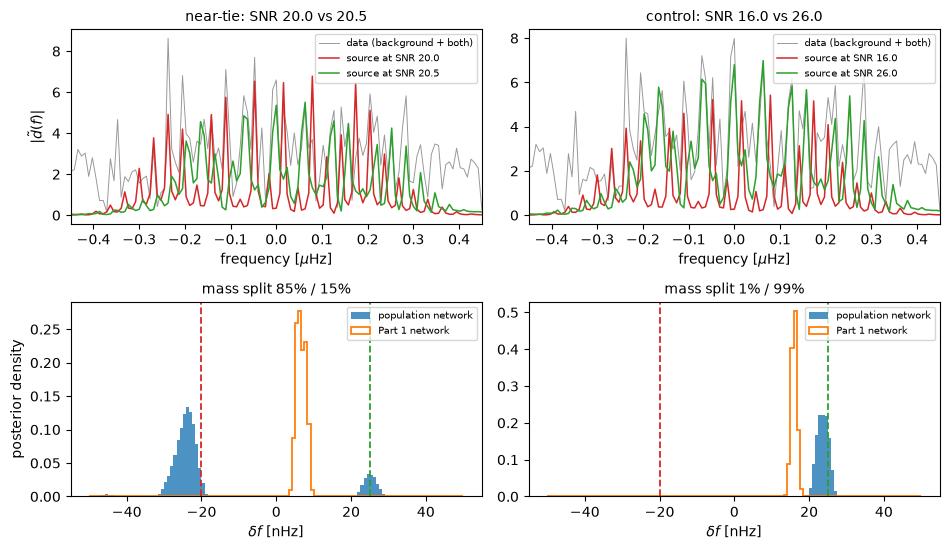

In [17]:
d_tie, th_tie, snr_tie, _ = controlled_tile(
    [with_snr(20.0, -2.0e-8, 6e-17, 1.0, 0.6),
     with_snr(20.5, 2.5e-8, 5e-17, 4.0, -0.3)], seed=13)
d_ctrl, th_ctrl, snr_ctrl, _ = controlled_tile(
    [with_snr(16.0, -2.0e-8, 6e-17, 1.0, 0.6),
     with_snr(26.0, 2.5e-8, 5e-17, 4.0, -0.3)], seed=13)

fig, axes = plt.subplots(2, 2, figsize=(9.6, 5.6))
for col, (d_t, th_t, s_t, title) in enumerate([
        (d_tie, th_tie, snr_tie, f"near-tie: SNR {snr_tie[0]:.1f} vs {snr_tie[1]:.1f}"),
        (d_ctrl, th_ctrl, snr_ctrl, f"control: SNR {snr_ctrl[0]:.1f} vs {snr_ctrl[1]:.1f}")]):
    ax = axes[0, col]
    z_t = torch.complex(d_t[:N], d_t[N:])
    ax.plot(f_band, torch.fft.fftshift(torch.fft.fft(z_t)).abs().cpu() / np.sqrt(N),
            lw=0.7, color="0.6", label="data (background + both)")
    for j, c in [(0, "C3"), (1, "C2")]:
        s_j = gbp.local_signal(th_t[j:j + 1])[0]
        ax.plot(f_band, torch.fft.fftshift(torch.fft.fft(s_j)).abs().cpu() / np.sqrt(N),
                lw=1.1, color=c, label=f"source at SNR {s_t[j]:.1f}")
    ax.set_xlim(-0.45, 0.45)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel(r"$|\tilde d(f)|$" if col == 0 else "")
    ax.set_xlabel(r"frequency $[\mu{\rm Hz}]$")

    dr, _ = gbp.tile_posterior_draws(flow2, stats, d_t[None], n_draws=8000)
    with torch.no_grad():
        zz, _ = flow_p1.sample_and_log_prob(8000, d_t[None])
    dp1 = (zz * gbc.P1_STD + gbc.P1_MEAN)[0]
    ax = axes[1, col]
    x = dr[0, :, 1].cpu().numpy() * 1e9
    ax.hist(x, bins=120, range=(-50, 50), density=True, color="C0", alpha=0.8,
            label="population network")
    ax.hist(dp1[:, 1].cpu().numpy() * 1e9, bins=120, range=(-50, 50), density=True,
            histtype="step", color="C1", lw=1.3, label="Part 1 network")
    for j, c in [(0, "C3"), (1, "C2")]:
        ax.axvline(float(th_t[j, 1]) * 1e9, color=c, lw=1.3, ls="--")
    split = (np.abs(x - float(th_t[0, 1]) * 1e9)
             < np.abs(x - float(th_t[1, 1]) * 1e9)).mean()
    ax.set_title(f"mass split {split:.0%} / {1 - split:.0%}", fontsize=10)
    ax.set_xlabel(r"$\delta f$ [nHz]")
    ax.legend(fontsize=7)
axes[1, 0].set_ylabel("posterior density")
plt.tight_layout()

The population network resolves the tie into two modes, each on a truth, and collapses
onto the winner in the control. The Part 1 network cannot represent this structure: its
affine flow produces a single distorted blob that answers neither "which source" nor
"where". The residual label-switching problem of crowded data has not been eliminated, it
has been confined to genuinely ambiguous tiles and expressed as posterior structure.

The frequency marginal shows the headline; the full five-dimensional posterior shows what
the compromise costs. Below, both networks' posteriors on the near-tie tile as a corner
plot, with both true parameter sets marked.

Text(0.5, 1.02, 'near-tie tile: population network (blue), Part 1 network (orange dashed);\ntruths: source A dotted red, source B dotted green')

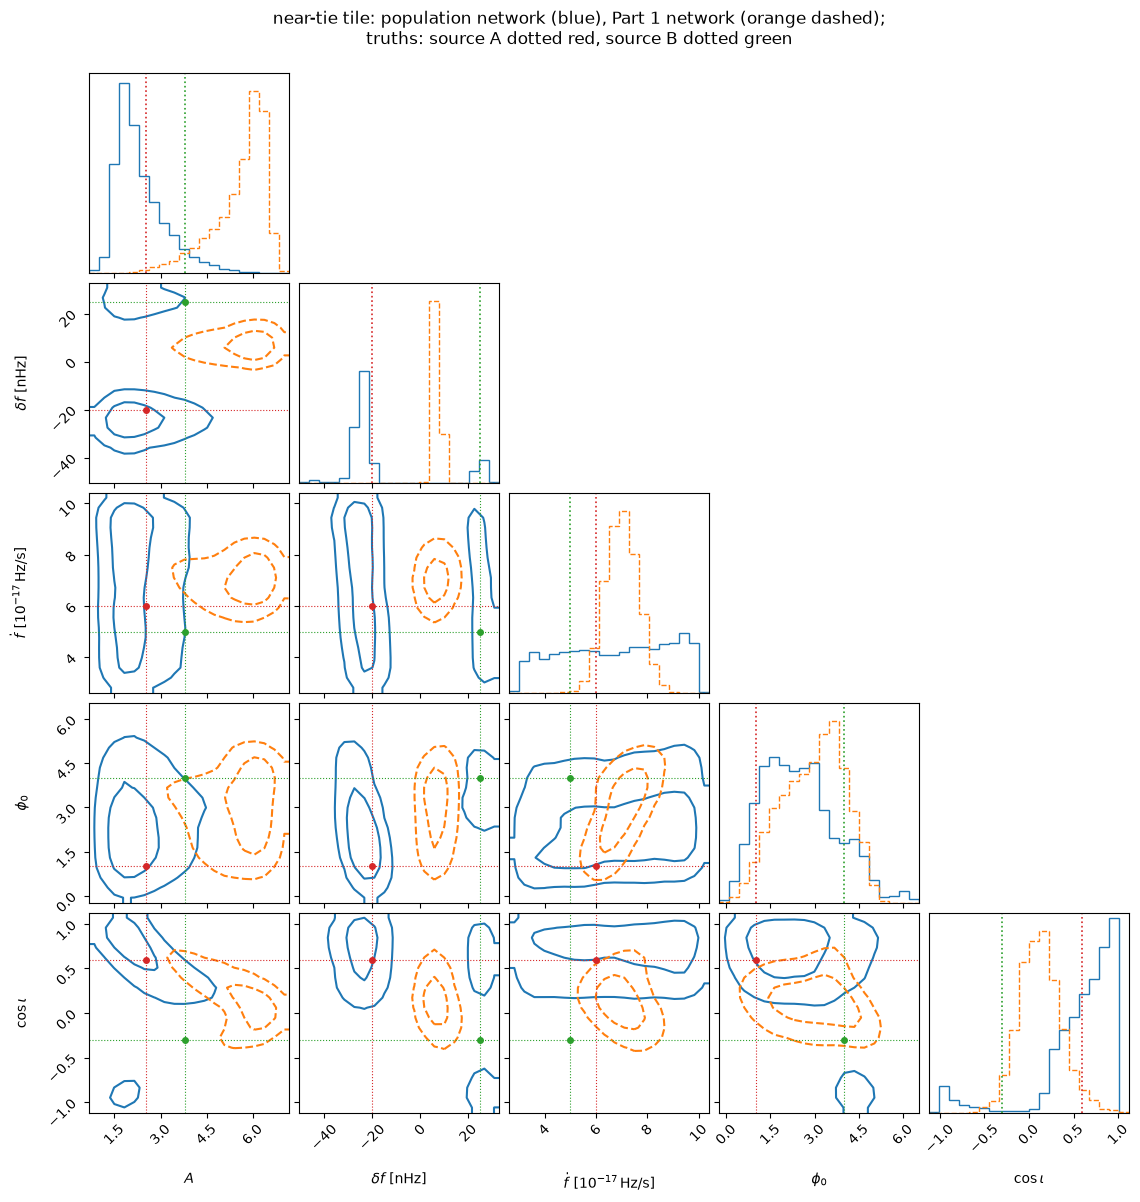

In [18]:
import corner

dr_tie2, _ = gbp.tile_posterior_draws(flow2, stats, d_tie[None], n_draws=8000)
with torch.no_grad():
    zz, _ = flow_p1.sample_and_log_prob(8000, d_tie[None])
dr_tie1 = (zz * gbc.P1_STD + gbc.P1_MEAN)[0]

SCALE_C = np.array([1.0, 1e9, 1e17, 1.0, 1.0])
LAB_C = [r"$A$", r"$\delta f$ [nHz]", r"$\dot f\ [10^{-17}\,{\rm Hz/s}]$", r"$\phi_0$",
         r"$\cos\iota$"]
x2 = dr_tie2[0].cpu().numpy() * SCALE_C
x1 = dr_tie1.cpu().numpy() * SCALE_C
tt = th_tie.cpu().numpy() * SCALE_C
lo = np.minimum(np.minimum(np.percentile(x2, 0.3, 0), np.percentile(x1, 0.3, 0)),
                tt.min(0))
hi = np.maximum(np.maximum(np.percentile(x2, 99.7, 0), np.percentile(x1, 99.7, 0)),
                tt.max(0))
pad = 0.06 * (hi - lo)
kw = dict(labels=LAB_C, range=[(a - p, b + p) for a, b, p in zip(lo, hi, pad)],
          levels=(0.5, 0.9), smooth=1.0, plot_datapoints=False, plot_density=False)
fig = corner.corner(x2, color="C0", hist_kwargs={"density": True}, **kw)
corner.corner(x1, fig=fig, color="C1", contour_kwargs={"linestyles": "dashed"},
              hist_kwargs={"density": True, "ls": "--"}, **kw)
grid = np.array(fig.axes).reshape(5, 5)
for j, col in [(0, "C3"), (1, "C2")]:
    for a in range(5):
        grid[a, a].axvline(tt[j, a], color=col, lw=1.2, ls=":")
        for b in range(a):
            grid[a, b].axvline(tt[j, b], color=col, lw=0.8, ls=":")
            grid[a, b].axhline(tt[j, a], color=col, lw=0.8, ls=":")
            grid[a, b].plot(tt[j, b], tt[j, a], "o", color=col, ms=4)
fig.suptitle("near-tie tile: population network (blue), Part 1 network (orange dashed);\n"
             "truths: source A dotted red, source B dotted green", y=1.02)

And the same comparison in data space: push each network's posterior draws through the
waveform model and compare the inferred signal with what is actually there.

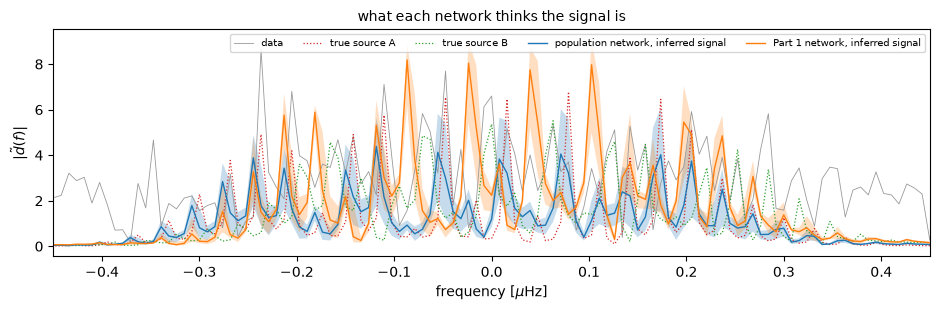

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 3.2))
z_t = torch.complex(d_tie[:N], d_tie[N:])
ax.plot(f_band, torch.fft.fftshift(torch.fft.fft(z_t)).abs().cpu() / np.sqrt(N),
        lw=0.6, color="0.6", label="data")
for j, col in [(0, "C3"), (1, "C2")]:
    s_j = gbp.local_signal(th_tie[j:j + 1])[0]
    ax.plot(f_band, torch.fft.fftshift(torch.fft.fft(s_j)).abs().cpu() / np.sqrt(N),
            lw=0.9, color=col, ls=":", label=f"true source {'AB'[j]}")
for draws, col, name in [(dr_tie2[0], "C0", "population network"),
                         (dr_tie1, "C1", "Part 1 network")]:
    lo_b, mid_b, hi_b = predictive_band(draws[:400])
    ax.plot(f_band, mid_b, lw=1.0, color=col, label=f"{name}, inferred signal")
    ax.fill_between(f_band, lo_b, hi_b, color=col, alpha=0.25, lw=0)
ax.set_xlim(-0.45, 0.45)
ax.set_xlabel(r"frequency $[\mu{\rm Hz}]$"); ax.set_ylabel(r"$|\tilde d(f)|$")
ax.set_title("what each network thinks the signal is", fontsize=10)
ax.legend(fontsize=7, ncol=5)
plt.tight_layout()

The corner plot spells out the compromise: Part 1's frequency sits between the two
sources, and its amplitude is inflated because a single template must soak up the power of
both. The data-space panel shows the consequence, a reconstructed source that exists in
neither injection: close enough to the data to look plausible, wrong enough that
subtracting it would corrupt both real binaries. The population network's bimodal
posterior is what refusing that mistake looks like.

**Subtract and look again.** The bimodal posterior supports a sequential reading: commit
to one mode, subtract that source, and ask the network what is left. If the first step
identifies source B, the second should identify source A, and vice versa. Both branch
orders are run below; the subtracted template is the per-mode posterior median (with a
circular mean for the phase).

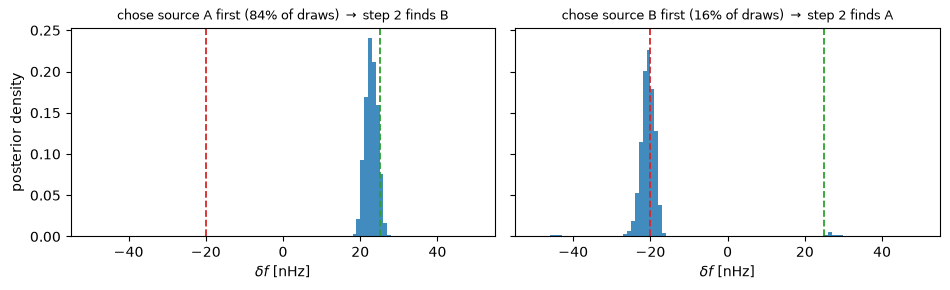

In [20]:
def mode_template(x_draws, mask):
    th = x_draws[mask.to(x_draws.device)]
    med = th.median(0).values.clone()
    med[3] = torch.atan2(th[:, 3].sin().mean(), th[:, 3].cos().mean()) % (2 * np.pi)
    return med[None]


dr_tie, _ = gbp.tile_posterior_draws(flow2, stats, d_tie[None], n_draws=8000)
x_tie = dr_tie[0]
near0 = (x_tie[:, 1] - th_tie[0, 1]).abs() < (x_tie[:, 1] - th_tie[1, 1]).abs()

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.0), sharey=True)
for ax, mask, first in [(axes[0], near0, 0), (axes[1], ~near0, 1)]:
    other = 1 - first
    th_fit = mode_template(x_tie, mask)
    sig = gbp.local_signal(th_fit)
    d_res = d_tie - torch.cat([sig.real.sum(0), sig.imag.sum(0)])
    dr_res, _ = gbp.tile_posterior_draws(flow2, stats, d_res[None], n_draws=4000)
    ax.hist(dr_res[0, :, 1].cpu().numpy() * 1e9, bins=100, range=(-50, 50), density=True,
            color="C0", alpha=0.85)
    for j, c in [(0, "C3"), (1, "C2")]:
        ax.axvline(float(th_tie[j, 1]) * 1e9, color=c, lw=1.3, ls="--")
    frac = float(mask.float().mean())
    ax.set_title(f"chose source {'AB'[first]} first ({frac:.0%} of draws) "
                 rf"$\rightarrow$ step 2 finds {'AB'[other]}", fontsize=9)
    ax.set_xlabel(r"$\delta f$ [nHz]")
axes[0].set_ylabel("posterior density")
plt.tight_layout()

Whichever source is subtracted first, the residual posterior identifies the other: the
two branches together recover both binaries. This is the seed of a global fit, and
section 9 applies it to the whole record.

---
# 9. Iterative subtraction

<!-- *(~4 min)* -->

Scan, subtract every catalog entry's posterior-median waveform from the record,
re-condition, scan again. Each pass fits whatever the previous subtraction left standing,
so sources that were masked by a loud neighbor get their turn, and imperfect subtractions
are refined rather than compounded. The interesting question is where this ends: does the
residual approach the instrument noise?

pass 1: 119 entries fitted (119 new), residual in-band variance 2.48 (instrument: 1.00, instrument + confusion: ~3.0)


pass 2: 14 entries fitted (1 new), residual in-band variance 2.45 (instrument: 1.00, instrument + confusion: ~3.0)


pass 3: 7 entries fitted (2 new), residual in-band variance 2.41 (instrument: 1.00, instrument + confusion: ~3.0)


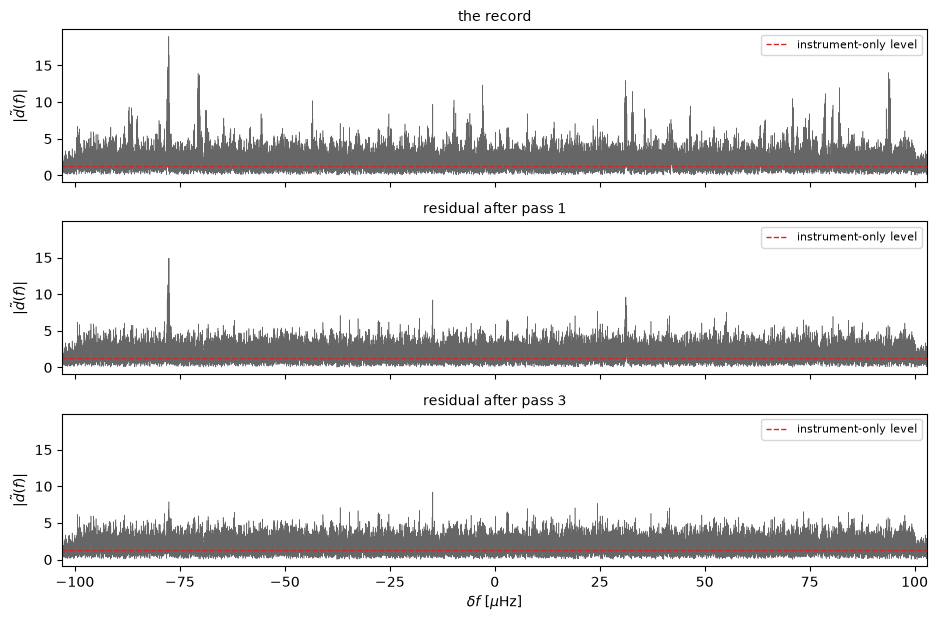

In [21]:
d_it = d.clone()
seen = set()
spectra = [("the record", spectrum(d))]
for it in range(1, 4):
    dc = gbc.condition_all(d_it)
    dr_i, sn_i = gbp.tile_posterior_draws(flow2, stats, dc, n_draws=256)
    st_i = sn_i.median(-1).values
    det_i = torch.nonzero(st_i > SNR_CAT).flatten().tolist()
    keep_i, _ = dedup(det_i, dr_i, st_i)
    th_fit = torch.stack([mode_template(dr_i[k], torch.ones(dr_i.shape[1],
                                                            dtype=torch.bool))[0]
                          for k in keep_i])
    th_fit[:, 1] = th_fit[:, 1] + gbw.DF_HAT[keep_i]
    d_it = d_it - gbw.signal_wide(th_fit).sum(0)
    new = [k for k in keep_i if k not in seen]
    seen.update(keep_i)
    var_band = gbc.condition_all(d_it).var()
    print(f"pass {it}: {len(keep_i)} entries fitted ({len(new)} new), "
          f"residual in-band variance {var_band:.2f} "
          f"(instrument: 1.00, instrument + confusion: ~3.0)")
    if it in (1, 3):
        spectra.append((f"residual after pass {it}", spectrum(d_it)))

torch.manual_seed(4)
ref = spectrum(torch.randn(2 * gbw.N_WIDE, device=device))
fig, axes = plt.subplots(len(spectra), 1, figsize=(9.5, 2.1 * len(spectra)),
                         sharex=True, sharey=True)
for ax, (title, sp) in zip(axes, spectra):
    ax.plot(f_axis, sp, lw=0.4, color="0.4")
    ax.axhline(np.mean(ref), color="C3", lw=1.0, ls="--", label="instrument-only level")
    ax.set_ylabel(r"$|\tilde d(f)|$")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
axes[-1].set_xlim(-103, 103)
axes[-1].set_xlabel(r"$\delta f\ [\mu{\rm Hz}]$")
plt.tight_layout()

The spikes go; the floor stays. Subtraction removes the resolved loud tail almost
completely, and later passes add only a few newly uncovered marginal sources, but the
residual settles well above the instrument line. That is not a failure of the method. The
floor is the integrated power of tens of thousands of sources below the catalog threshold,
and no subtraction scheme can remove what cannot be individually identified: pushing the
cut lower just subtracts noise-shaped templates. This is the confusion limit, the same
reason the real LISA data analysis characterizes the galactic foreground statistically
rather than source by source. The population network handles it the only way possible: not
by removing the floor, but by owning it in the error bars, which section 5 certified.

---
# 10. Exercises and outlook

**Exercises:**

- **(a) Turn the instrument off.** Re-run the notebook with
  `pop = gbp.PopulationSettings(noise_std=0.0)` (the checkpoint must be retrained for that
  population: one `train_confusion_flow.py` run). Posterior widths shrink but do not
  vanish; the confusion floor is a noise source with its own statistics.
- **(b) Dial the Galaxy.** Halve and double `rho` at fixed everything else and re-run the
  training script. How do posterior widths at fixed SNR scale with the confusion density?
- **(c) Sweep the tie.** Vary the SNR ratio in section 8's experiment from 1.0 to 1.5,
  over several noise seeds, and plot the average mass split against it. You are measuring
  $P(\text{source 1 is loudest} \mid d)$, and it should move smoothly from balanced to
  certain.
- **(d) Subtract deeper.** Lower the subtraction cut in section 9 below the catalog floor
  and watch the residual variance: at some depth the subtracted templates are more noise
  than signal and the residual stops improving. Where, and why there?

**Outlook.** Two ideas did the work of this tutorial series. Heterodyne conditioning turns
one narrow-prior network into a search-plus-inference machine over an arbitrarily wide
band, and the training distribution, not the architecture, decides what a posterior means:
white-noise single-source training gave Part 1 its speed and its blind spots, and
population training gave Part 2 calibrated inference in data where the noise itself is
made of signals. The real LISA global fit adds sky position, frequency evolution, other
source classes and instrument artifacts, but the shape of the problem, tens of thousands
of overlapping sources amortized into per-source posteriors, is the one this toy now
solves end to end.